# WAIS Data: IMBIE Observations & IPCC AR6 Projections

This notebook loads and visualizes WAIS (West Antarctic Ice Sheet) sea-level contributions:
- **IMBIE** observational time series (1992–2020)
- **IPCC AR6** WAIS projections: dist_components (all workflows × SSPs)
- **IPCC AR6** full sample components (all workflows × SSPs)
- **ISMIP6** model outputs (volume above flotation → SLE)

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
import glob
import os
import sys
from pathlib import Path

# Project paths
PROJECT_ROOT = Path('..').resolve()
DATA_RAW = PROJECT_ROOT / 'data' / 'raw'
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'
HDF5_PATH = DATA_PROCESSED / 'slr_processed_data.h5'

DIST_COMPONENTS_DIR = DATA_RAW / 'ipcc_ar6' / 'slr' / 'ar6' / 'global' / 'dist_components'
FULL_SAMPLE_DIR = DATA_RAW / 'ipcc_ar6' / 'slr' / 'ar6' / 'global' / 'full_sample_components'
ISMIP6_DIR = DATA_RAW / 'ice_sheets' / 'ismip6' / 'ComputedScalarsPaper'

# Constants
BASELINE_YEAR = 2000.0
M_TO_MM = 1000.0
OCEAN_AREA = 3.625e14  # m^2

# SSP scenarios
SSP_SCENARIOS = ['ssp119', 'ssp126', 'ssp245', 'ssp370', 'ssp585']

# AR6 WAIS workflows
WAIS_WORKFLOWS = [
    'icesheets-ar5-icesheets',
    'icesheets-dp20-icesheet',
    'icesheets-ipccar6-bambericesheet',
    'icesheets-ipccar6-ismipemuicesheet',
    'icesheets-ipccar6-larmipicesheet',
]

plt.style.use('seaborn-v0_8-poster')
print('Setup complete.')

Setup complete.


## 1. Load IMBIE WAIS from HDF5

In [2]:
# Load IMBIE WAIS data from HDF5 store
store = pd.HDFStore(str(HDF5_PATH), mode='r')
imbie_wais = store['/harmonized/df_imbie_wais_h'].copy()
store.close()

# Data is in meters (SLE), cumulative_mass_balance
# decimal_year for time axis
imbie_time = imbie_wais['decimal_year'].values
imbie_sle = imbie_wais['cumulative_mass_balance'].values  # meters, positive = SLR
imbie_sle_sigma = imbie_wais['cumulative_mass_balance_sigma'].values

# Rebaseline to year 2000
idx_2000 = np.argmin(np.abs(imbie_time - BASELINE_YEAR))
imbie_sle_bl = imbie_sle - imbie_sle[idx_2000]
imbie_sle_mm = imbie_sle_bl * M_TO_MM  # convert to mm
imbie_sigma_mm = np.abs(imbie_sle_sigma) * M_TO_MM

print(f'IMBIE WAIS: {imbie_time[0]:.1f} – {imbie_time[-1]:.1f}')
print(f'  Value at 2000: {imbie_sle[idx_2000]*M_TO_MM:.2f} mm (set to 0)')
print(f'  Value at end:  {imbie_sle_mm[-1]:.2f} mm')
print(f'  Shape: {imbie_sle.shape}')

IMBIE WAIS: 1992.0 – 2020.9
  Value at 2000: -0.09 mm (set to 0)
  Value at end:  5.77 mm
  Shape: (348,)


## 2. Fit & extrapolate IMBIE WAIS using kinematics from HDF5

In [3]:
# Fit quadratic to IMBIE WAIS cumulative mass balance for extrapolation
# SLE(t) = 0.5*a*(t-t0)^2 + v0*(t-t0) + c
# where a = acceleration, v0 = rate at t0
t_centered = imbie_time - BASELINE_YEAR
coeffs = np.polyfit(t_centered, imbie_sle_mm, 2)
poly_fit = np.poly1d(coeffs)

# Extrapolation period
t_extrap = np.arange(imbie_time[-1], 2101, 1.0)
t_extrap_centered = t_extrap - BASELINE_YEAR
sle_extrap_mm = poly_fit(t_extrap_centered)

# Also compute fit over observation period for display
sle_fit_mm = poly_fit(t_centered)

accel = 2 * coeffs[0]  # mm/yr^2
rate_2000 = coeffs[1]  # mm/yr at t0=2000
print(f'Quadratic fit: accel = {accel:.4f} mm/yr², rate(2000) = {rate_2000:.4f} mm/yr')
print(f'Extrapolated SLE at 2100: {poly_fit(100):.1f} mm')

Quadratic fit: accel = 0.0152 mm/yr², rate(2000) = 0.1485 mm/yr
Extrapolated SLE at 2100: 91.0 mm


## 3. Load IPCC AR6 WAIS dist_components (all workflows × SSPs)

In [4]:
def read_ar6_wais_dist(workflow, scenario, dist_dir=DIST_COMPONENTS_DIR):
    """Read AR6 WAIS dist_components NetCDF for a given workflow and scenario.
    
    Returns dict with years, quantiles, and sea_level_change (mm),
    or None if file doesn't exist.
    """
    fname = f'{workflow}-{scenario}_WAIS_globalsl.nc'
    fpath = dist_dir / fname
    if not fpath.exists():
        return None
    ds = xr.open_dataset(str(fpath))
    result = {
        'years': ds['years'].values,
        'quantiles': ds['quantiles'].values,
        'slc': ds['sea_level_change'].values[:, :, 0],  # (quantiles, years)
        'workflow': workflow,
        'scenario': scenario,
        'baseyear': int(ds.attrs.get('baseyear', 2005)),
    }
    ds.close()
    return result


# Load all workflow × SSP combinations
ar6_dist = {}  # key: (workflow, scenario)
for wf in WAIS_WORKFLOWS:
    for ssp in SSP_SCENARIOS:
        data = read_ar6_wais_dist(wf, ssp)
        if data is not None:
            ar6_dist[(wf, ssp)] = data

print(f'Loaded {len(ar6_dist)} AR6 dist_component files.')
print('\nAvailability matrix:')
for wf in WAIS_WORKFLOWS:
    short_wf = wf.replace('icesheets-', '')
    avail = [ssp for ssp in SSP_SCENARIOS if (wf, ssp) in ar6_dist]
    print(f'  {short_wf:35s}: {avail}')

Loaded 21 AR6 dist_component files.

Availability matrix:
  ar5-icesheets                      : ['ssp119', 'ssp126', 'ssp245', 'ssp370', 'ssp585']
  dp20-icesheet                      : ['ssp126', 'ssp245', 'ssp585']
  ipccar6-bambericesheet             : ['ssp126', 'ssp245', 'ssp585']
  ipccar6-ismipemuicesheet           : ['ssp119', 'ssp126', 'ssp245', 'ssp370', 'ssp585']
  ipccar6-larmipicesheet             : ['ssp119', 'ssp126', 'ssp245', 'ssp370', 'ssp585']


## 4. Load IPCC AR6 WAIS full_sample_components (all workflows × SSPs)

In [5]:
def read_ar6_wais_full_sample(workflow, scenario, sample_dir=FULL_SAMPLE_DIR):
    """Read AR6 WAIS full_sample_components NetCDF.
    
    Returns dict with years, samples array (n_samples, n_years) in mm,
    or None if file doesn't exist.
    """
    fname = f'{workflow}-{scenario}_WAIS_globalsl.nc'
    fpath = sample_dir / fname
    if not fpath.exists():
        return None
    ds = xr.open_dataset(str(fpath))
    result = {
        'years': ds['years'].values,
        'samples': ds['sea_level_change'].values[:, :, 0],  # (samples, years) in mm
        'n_samples': ds.sizes['samples'],
        'workflow': workflow,
        'scenario': scenario,
        'baseyear': int(ds.attrs.get('baseyear', 2005)),
    }
    ds.close()
    return result


# Load all workflow × SSP combinations
ar6_full = {}  # key: (workflow, scenario)
for wf in WAIS_WORKFLOWS:
    for ssp in SSP_SCENARIOS:
        data = read_ar6_wais_full_sample(wf, ssp)
        if data is not None:
            ar6_full[(wf, ssp)] = data

print(f'Loaded {len(ar6_full)} AR6 full_sample_component files.')
print('\nSample sizes:')
for (wf, ssp), d in sorted(ar6_full.items()):
    short_wf = wf.replace('icesheets-', '')
    print(f'  {short_wf:35s} {ssp}: {d["n_samples"]:6d} samples')

Loaded 21 AR6 full_sample_component files.

Sample sizes:
  ar5-icesheets                       ssp119:  20000 samples
  ar5-icesheets                       ssp126:  20000 samples
  ar5-icesheets                       ssp245:  20000 samples
  ar5-icesheets                       ssp370:  20000 samples
  ar5-icesheets                       ssp585:  20000 samples
  dp20-icesheet                       ssp126:  20000 samples
  dp20-icesheet                       ssp245:  20000 samples
  dp20-icesheet                       ssp585:  20000 samples
  ipccar6-bambericesheet              ssp126:  20000 samples
  ipccar6-bambericesheet              ssp245:  20000 samples
  ipccar6-bambericesheet              ssp585:  20000 samples
  ipccar6-ismipemuicesheet            ssp119:  20000 samples
  ipccar6-ismipemuicesheet            ssp126:  20000 samples
  ipccar6-ismipemuicesheet            ssp245:  20000 samples
  ipccar6-ismipemuicesheet            ssp370:  20000 samples
  ipccar6-ismipemuicesheet 

## 5. Load ISMIP6 SLE outputs (all models, WAIS = region 2)

In [6]:
def read_ismip6_wais_sle(filepath):
    """Read ISMIP6 ctrl-subtracted ivaf file, extract WAIS (region_2), convert to SLE (mm).
    
    SLE (mm) = -delta_ivaf * rhoi / (rhow * ocean_area) * 1000
    Positive SLE = sea level rise (ice loss).
    """
    ds = xr.open_dataset(filepath, decode_times=False)
    time = ds['time'].values  # decimal years
    
    # WAIS = region_2 in ISMIP6 convention
    if 'ivaf_region_2' not in ds.data_vars:
        ds.close()
        return None
    
    wais_ivaf = ds['ivaf_region_2'].values  # m^3, ctrl-subtracted
    
    # Use rhoi/rhow from file if available, otherwise use standard values
    rhoi = float(ds['rhoi'].values) if 'rhoi' in ds.data_vars else 917.0
    rhow = float(ds['rhow'].values) if 'rhow' in ds.data_vars else 1028.0
    ds.close()
    
    # Convert ivaf anomaly to SLE in mm
    # Negative delta_ivaf (ice loss) → positive SLE
    sle_mm = -wais_ivaf * rhoi / (rhow * OCEAN_AREA) * M_TO_MM
    
    # Parse model name and experiment from filename
    bname = os.path.basename(filepath)
    parts = bname.replace('computed_ivaf_minus_ctrl_proj_AIS_', '').replace('.nc', '')
    tokens = parts.split('_')
    group = tokens[0]
    model = tokens[1]
    experiment = '_'.join(tokens[2:])
    
    return {
        'time': time,
        'sle_mm': sle_mm,
        'group': group,
        'model': model,
        'experiment': experiment,
        'label': f'{group}/{model}/{experiment}',
    }


# Load all ISMIP6 ctrl-subtracted ivaf files
ismip6_files = sorted(glob.glob(str(ISMIP6_DIR / '*' / '*' / '*' / 'computed_ivaf_minus_ctrl_proj_AIS_*.nc')))
print(f'Found {len(ismip6_files)} ISMIP6 ctrl-subtracted ivaf files.')

ismip6_wais = []
for f in ismip6_files:
    result = read_ismip6_wais_sle(f)
    if result is not None:
        ismip6_wais.append(result)

print(f'Loaded {len(ismip6_wais)} ISMIP6 WAIS SLE time series.')

# Summary
groups = set(d['group'] for d in ismip6_wais)
models = set(f"{d['group']}/{d['model']}" for d in ismip6_wais)
experiments = set(d['experiment'] for d in ismip6_wais)
print(f'  Groups: {len(groups)}, Models: {len(models)}, Experiments: {len(experiments)}')

Found 188 ISMIP6 ctrl-subtracted ivaf files.


Loaded 188 ISMIP6 WAIS SLE time series.
  Groups: 13, Models: 15, Experiments: 75


## Figure 1: IMBIE WAIS + IPCC AR6 Workflows

Plotting 5 workflows for ssp245
IMBIE offset at 2005 (rel. to 2000): 0.75 mm


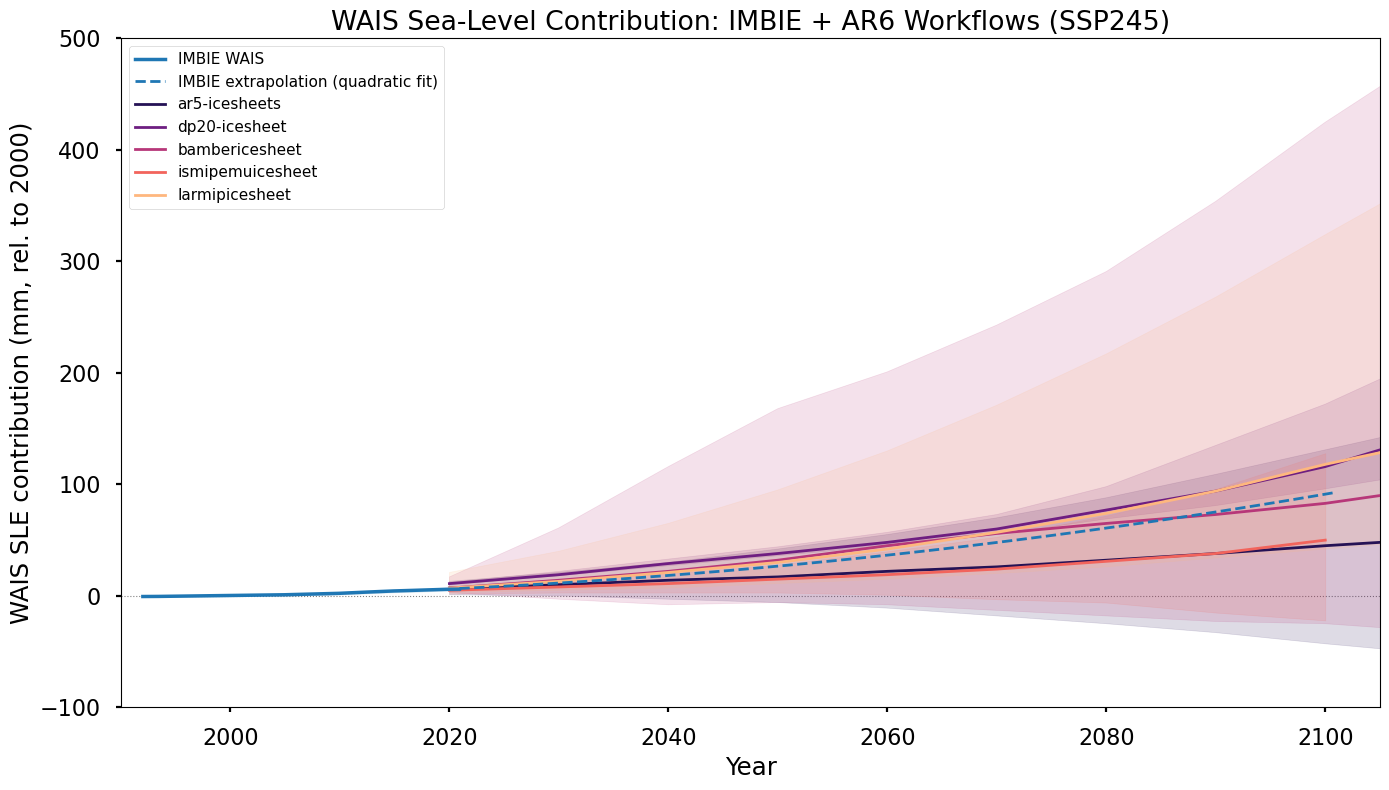

In [7]:
# ==================================================
# Figure 1: IMBIE WAIS + IPCC AR6 Workflows
# ==================================================

# ── User configuration ──
ssp_show = 'ssp245'  # Change to any SSP: ssp119, ssp126, ssp245, ssp370, ssp585

# ── Collect AR6 workflows for the selected SSP ──
workflows_to_plot = {}
for (wf, ssp), data in ar6_dist.items():
    if ssp == ssp_show:
        workflows_to_plot[wf] = data

n_workflows = len(workflows_to_plot)
print(f'Plotting {n_workflows} workflows for {ssp_show}')

# ── Compute IMBIE offset at AR6 baseyear (2005) for rebaselining ──
# AR6 projections are relative to 2005 (baseyear=2005, value=0 at 2005)
# IMBIE is already baselined to 2000
# To put AR6 on the same baseline: AR6_rebased = AR6_original + IMBIE_value_at_2005
idx_2005 = np.argmin(np.abs(imbie_time - 2005.0))
imbie_offset_2005_mm = imbie_sle_mm[idx_2005]  # IMBIE value at 2005 relative to 2000
print(f'IMBIE offset at 2005 (rel. to 2000): {imbie_offset_2005_mm:.2f} mm')

# ── Colormap for workflows ──
cmap = mpl.colormaps['magma']
# Evenly space colors, avoiding extremes (too light/dark)
wf_colors = [cmap(0.15 + 0.7 * i / max(n_workflows - 1, 1)) for i in range(n_workflows)]

# ── Figure ──
fig, ax = plt.subplots(figsize=(14, 8))

# 1. IMBIE observations
ax.plot(imbie_time, imbie_sle_mm, color='tab:blue', lw=2.5, label='IMBIE WAIS', zorder=55)
ax.fill_between(imbie_time,
                imbie_sle_mm - 2 * imbie_sigma_mm,
                imbie_sle_mm + 2 * imbie_sigma_mm,
                color='tab:blue', alpha=0.15, zorder=54)

# 2. IMBIE extrapolation (quadratic fit)
ax.plot(t_extrap, sle_extrap_mm, color='tab:blue', ls='--', lw=2, 
        label='IMBIE extrapolation (quadratic fit)', zorder=54)

# 3. AR6 workflows (median + 5–95% CI)
for i, (wf, data) in enumerate(sorted(workflows_to_plot.items())):
    years = data['years']
    quantiles = data['quantiles']
    slc = data['slc']  # (quantiles, years) in mm
    
    # Extract key quantiles
    idx_p5 = np.argmin(np.abs(quantiles - 0.05))
    idx_p50 = np.argmin(np.abs(quantiles - 0.50))
    idx_p95 = np.argmin(np.abs(quantiles - 0.95))
    
    median = slc[idx_p50, :] + imbie_offset_2005_mm
    p5 = slc[idx_p5, :] + imbie_offset_2005_mm
    p95 = slc[idx_p95, :] + imbie_offset_2005_mm
    
    color = wf_colors[i]
    short_name = wf.replace('icesheets-', '').replace('ipccar6-', '')
    
    ax.plot(years, median, color=color, lw=2, label=short_name, zorder=3)
    ax.fill_between(years, p5, p95, color=color, alpha=0.15, zorder=2)

# ── Formatting ──
ax.set_xlabel('Year')
ax.set_ylabel('WAIS SLE contribution (mm, rel. to 2000)')
ax.set_title(f'WAIS Sea-Level Contribution: IMBIE + AR6 Workflows ({ssp_show.upper()})')
ax.axhline(0, color='gray', ls=':', lw=0.8, zorder=1)
ax.set_xlim(1990, 2105)
ax.set_ylim([-100,500])
ax.legend(loc='upper left', fontsize=11, framealpha=0.9)

plt.tight_layout()
fig.savefig('../figures/wais_data_ipccar6_fig1_imbie_ipccar6workflows.png',
            dpi=200, bbox_inches='tight')
plt.show()

## Figure 2: IMBIE WAIS + AR6 Full Sample Components

Plotting 5 full-sample workflows for ssp245
IMBIE offset at 2005 (rel. to 2000): 0.75 mm


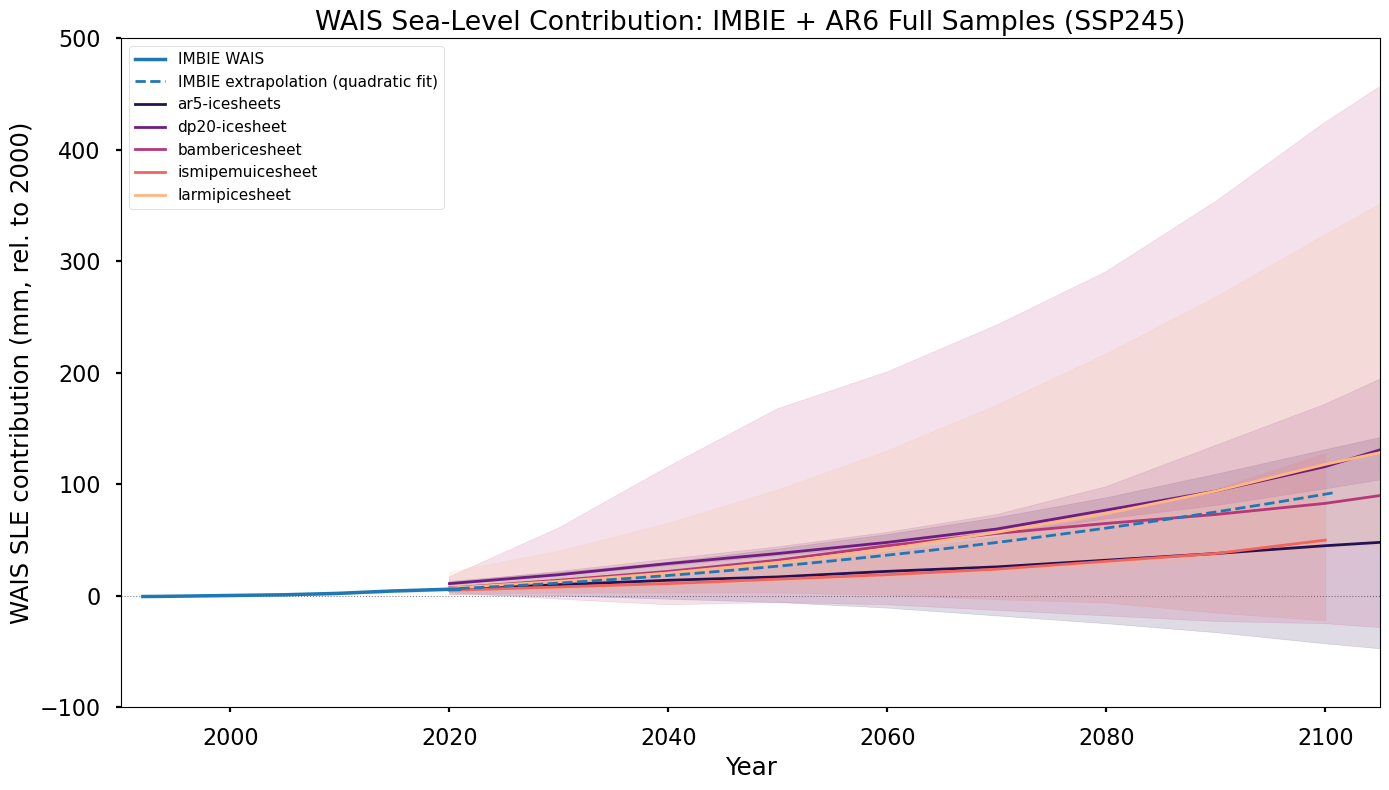

In [8]:
# ==================================================
# Figure 2: IMBIE WAIS + AR6 Full Sample Components
# ==================================================

# ── User configuration ──
ssp_show_fig2 = 'ssp245'  # Change to any SSP: ssp119, ssp126, ssp245, ssp370, ssp585

# ── Collect full-sample workflows for the selected SSP ──
full_to_plot = {}
for (wf, ssp), data in ar6_full.items():
    if ssp == ssp_show_fig2:
        full_to_plot[wf] = data

n_full = len(full_to_plot)
print(f'Plotting {n_full} full-sample workflows for {ssp_show_fig2}')

# ── IMBIE offset at AR6 baseyear (2005) ──
idx_2005 = np.argmin(np.abs(imbie_time - 2005.0))
imbie_offset_2005_mm = imbie_sle_mm[idx_2005]
print(f'IMBIE offset at 2005 (rel. to 2000): {imbie_offset_2005_mm:.2f} mm')

# ── Colormap ──
cmap = mpl.colormaps['magma']
full_colors = [cmap(0.15 + 0.7 * i / max(n_full - 1, 1)) for i in range(n_full)]

# ── Figure ──
fig, ax = plt.subplots(figsize=(14, 8))

# 1. IMBIE observations
ax.plot(imbie_time, imbie_sle_mm, color='tab:blue', lw=2.5, label='IMBIE WAIS', zorder=5)
ax.fill_between(imbie_time,
                imbie_sle_mm - 2 * imbie_sigma_mm,
                imbie_sle_mm + 2 * imbie_sigma_mm,
                color='tab:blue', alpha=0.15, zorder=4)

# 2. IMBIE extrapolation (quadratic fit)
ax.plot(t_extrap, sle_extrap_mm, color='tab:blue', ls='--', lw=2,
        label='IMBIE extrapolation (quadratic fit)', zorder=4)

# 3. AR6 full-sample workflows (median + 5–95% CI computed from samples)
for i, (wf, data) in enumerate(sorted(full_to_plot.items())):
    years = data['years']
    samples = data['samples']  # (n_samples, n_years) in mm

    median = np.median(samples, axis=0) + imbie_offset_2005_mm
    p5 = np.percentile(samples, 5, axis=0) + imbie_offset_2005_mm
    p95 = np.percentile(samples, 95, axis=0) + imbie_offset_2005_mm

    color = full_colors[i]
    short_name = wf.replace('icesheets-', '').replace('ipccar6-', '')

    ax.plot(years, median, color=color, lw=2, label=short_name, zorder=3)
    ax.fill_between(years, p5, p95, color=color, alpha=0.15, zorder=2)

# ── Formatting ──
ax.set_xlabel('Year')
ax.set_ylabel('WAIS SLE contribution (mm, rel. to 2000)')
ax.set_title(f'WAIS Sea-Level Contribution: IMBIE + AR6 Full Samples ({ssp_show_fig2.upper()})')
ax.axhline(0, color='gray', ls=':', lw=0.8, zorder=1)
ax.set_xlim(1990, 2105)
ax.set_ylim([-100,500])
ax.legend(loc='upper left', fontsize=11, framealpha=0.9)

plt.tight_layout()
fig.savefig('../figures/wais_data_ipccar6_fig2_imbie_ipccar6components.png',
            dpi=200, bbox_inches='tight')
plt.show()

## Figure 3: IMBIE WAIS + ISMIP6 Model Outputs

Plotting 188 ISMIP6 runs from 15 models


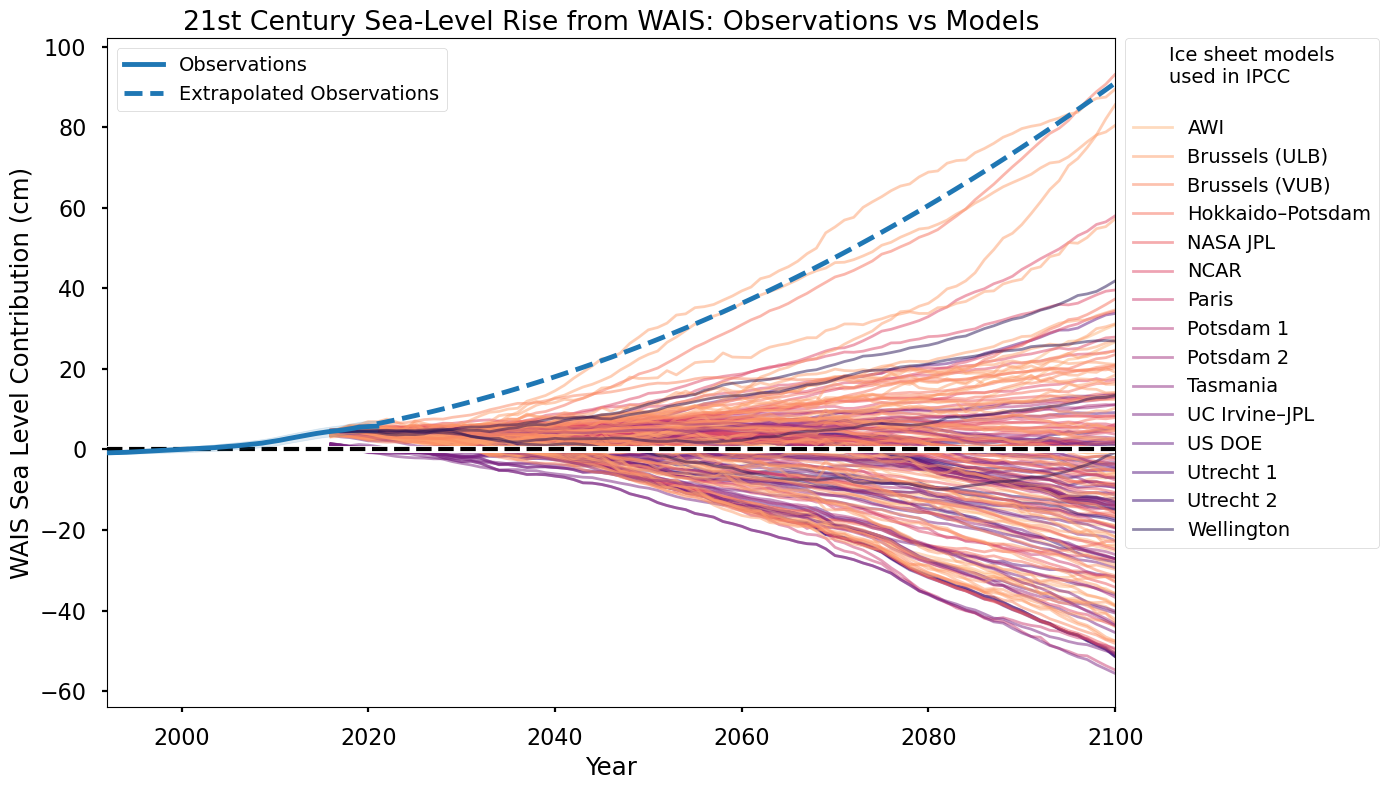

In [47]:
# ==================================================
# Figure 3: IMBIE WAIS + ISMIP6 Model Outputs
# ==================================================

# ── Plain-language model name mapping ──
# Original group/model → short name for non-specialists
# Naming convention: institution location (or common abbreviation)
MODEL_NAMES = {
    'AWI/PISM1':       'AWI',            # Alfred Wegener Inst., Bremerhaven
    'DOE/MALI':        'US DOE',         # Dept. of Energy / Los Alamos
    'ILTS/PIK':        'Hokkaido–Potsdam',  # ILTS Sapporo + PIK Potsdam
    'IMAU/IMAUICE1':   'Utrecht 1',      # Utrecht University, config 1
    'IMAU/IMAUICE2':   'Utrecht 2',      # Utrecht University, config 2
    'JPL1/ISSM':       'NASA JPL',       # Jet Propulsion Laboratory
    'LSCE/GRISLI':     'Paris',          # Lab. des Sciences du Climat
    'NCAR/CISM':       'NCAR',           # Nat. Center for Atmos. Research
    'PIK/PISM1':       'Potsdam 1',      # PIK, config 1
    'PIK/PISM2':       'Potsdam 2',      # PIK, config 2
    'UCIJPL/ISSM':     'UC Irvine–JPL',  # UC Irvine / JPL collaboration
    'ULB/fETISh':      'Brussels (ULB)', # Univ. Libre de Bruxelles
    'UTAS/ElmerIce':   'Tasmania',       # Univ. of Tasmania
    'VUB/AISMPALEO':   'Brussels (VUB)', # Vrije Univ. Brussel
    'VUW/PISM':        'Wellington',     # Victoria Univ. of Wellington
}

# ── IMBIE offset at AR6 baseyear (2005) for reference ──
idx_2005 = np.argmin(np.abs(imbie_time - 2005.0))
imbie_offset_2005_mm = imbie_sle_mm[idx_2005]

# ── Assign a unique color per model, ordered A→Z by plain-language name ──
unique_models = sorted(set(f"{d['group']}/{d['model']}" for d in ismip6_wais))
models_alpha = sorted(unique_models, key=lambda m: MODEL_NAMES.get(m, m))
n_models = len(models_alpha)
cmap = mpl.colormaps['magma_r']
model_colors = {m: cmap(0.15 + 0.7 * i / max(n_models - 1, 1))
                for i, m in enumerate(models_alpha)}

print(f'Plotting {len(ismip6_wais)} ISMIP6 runs from {n_models} models')

# ── Figure ──
fig, ax = plt.subplots(figsize=(14, 8))

# 1. IMBIE observations
h_obs = ax.plot(imbie_time, imbie_sle_mm, color='tab:blue', lw=3.5,
                label='IMBIE WAIS', zorder=1e4)[0]
h_fill = ax.fill_between(imbie_time,
                         imbie_sle_mm - 2 * imbie_sigma_mm,
                         imbie_sle_mm + 2 * imbie_sigma_mm,
                         color='tab:blue', alpha=0.15, zorder=1e4)

# 2. IMBIE extrapolation (quadratic fit)
h_extrap = ax.plot(t_extrap, sle_extrap_mm, color='tab:blue', ls='--', lw=3.5,
                   label='IMBIE extrapolation', zorder=1e4)[0]

# 3. ISMIP6 model runs
plotted_models = set()
model_handles = {}
for d in ismip6_wais:
    t = d['time']
    sle = d['sle_mm']
    model_key = f"{d['group']}/{d['model']}"
    color = model_colors[model_key]

    # Find IMBIE value at experiment start for rebaselining
    idx_start = np.argmin(np.abs(imbie_time - t[0]))
    offset = imbie_sle_mm[idx_start]

    h = ax.plot(t, sle + offset, color=color, lw=2, alpha=0.5, zorder=2)[0]

    if model_key not in plotted_models:
        model_handles[model_key] = h
        plotted_models.add(model_key)

# ── Legend 1 (top left): observations ──
obs_handles = [h_obs, h_extrap]
obs_labels = ['Observations', 'Extrapolated Observations']
leg_obs = ax.legend(obs_handles, obs_labels,
                    loc='upper left', fontsize=14, framealpha=0.9)
ax.add_artist(leg_obs)  # keep this legend when adding the second

# ── Legend 2 (right of axes): ISMIP6 models, alphabetical by plain-language name ──
model_handles_sorted = [model_handles[m] for m in models_alpha]
model_labels_sorted = [MODEL_NAMES.get(m, m) for m in models_alpha]
leg_models = ax.legend(model_handles_sorted, model_labels_sorted,
                       loc='upper left',
                       bbox_to_anchor=(1.01, 1.0),
                       fontsize=14, framealpha=0.9,
                       title='Ice sheet models\nused in IPCC\n', title_fontsize=14,
                       borderaxespad=0)

# ── Formatting ──
ax.set_xlabel('Year')
ax.set_ylabel('WAIS Sea Level Contribution (cm)')
ax.set_title('21st Century Sea-Level Rise from WAIS: Observations vs Models')
ax.axhline(0, color='w', ls='-', lw=5, zorder=999)
ax.axhline(0, color='k', ls='--', lw=3, zorder=1e3)
ax.set_xlim(1992, 2100)

plt.tight_layout()
fig.savefig('../figures/wais_data_ipccar6_fig3_imbie_ismip6.png',
            dpi=200, bbox_inches='tight')
plt.show()